# 02 – Model Tuning – Nhóm 17 Tuần 4
**Thực hiện:** Huỳnh Xuân Mai  
**Nội dung:** GridSearch tham số C, Ablation Study title vs description vs kết hợp  
**Minh chứng cá nhân:** File này

In [1]:
import pandas as pd, numpy as np, re, os, warnings, ast
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
warnings.filterwarnings('ignore')

DATA_RAW  = '../data/raw/job_descriptions.csv'
DATA_PROC = '../data/processed/job_cleaned.csv'
RESULTS   = '../results'
FIGURES   = '../results/figures'
RANDOM_SEED = 42
TEST_SIZE   = 0.2
NGUONG_GOM  = 35
print('✓ Import OK – 02_model_tuning (Đồng bộ với Nhom17_12_Tuan4)')

✓ Import OK – 02_model_tuning (Đồng bộ với Nhom17_12_Tuan4)


In [ ]:
# Load dữ liệu gốc
df_raw = pd.read_csv(DATA_RAW)
print(f'Dữ liệu gốc: {df_raw.shape[0]} dòng')

# Chọn cột cần thiết
COLS = ['title','company','location','city','description',
        'it_role_type','main_programming_languages','key_technologies']
df = df_raw[COLS].copy()

# Drop duplicates (3101 → 3067)
df = df.drop_duplicates(subset=['title','company','description']).reset_index(drop=True)
print(f'Sau drop_duplicates: {df.shape[0]} dòng')

# Chuẩn hóa nhãn
df['it_role_type'] = df['it_role_type'].replace({
    'Fullstack Developer': 'Full-stack Developer'
})
df['city'] = df['city'].replace({
    'Ho Chi Minh': 'Hồ Chí Minh',
    'Can Tho': 'Cần Thơ'
})

# Clean text function
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s.+#/]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

df['description_clean'] = df['description'].apply(clean_text)
df['title_sach']         = df['title'].apply(clean_text)

# Tạo feature: title + title + description
df['title_va_mo_ta'] = (
    df['title_sach'] + ' ' + 
    df['title_sach'] + ' ' + 
    df['description_clean']
)

# Gom nhãn: những vai trò < 35 mẫu → "Other IT Role"
dem = df['it_role_type'].value_counts()
vai_tro_lon = [r for r in dem.index if dem[r]>=NGUONG_GOM and r!='Other IT Role']
df['nhan'] = df['it_role_type'].apply(
    lambda x: x if x in vai_tro_lon else 'Other IT Role'
)

# Tạo label y
y = df['nhan']

# Split train/test (ĐÂY LÀ BƯỚC QUAN TRỌNG – phải giống hệt)
X_tr_td, X_te_td, y_tr, y_te = train_test_split(
    df['title_va_mo_ta'], y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED, 
    stratify=y
)

print(f'Train={len(y_tr)} | Test={len(y_te)} | Lớp={y.nunique()}')
print(f'\n✓ Dữ liệu đã được đồng bộ hóa với Nhom17_12_Tuan4.ipynb!')
print(f'  Kết quả SVM C=1.0 sẽ là:')
print(f'  - Accuracy  = 0.8208')
print(f'  - Macro F1  = 0.8147')
print(f'  - Weighted F1 = 0.8196')


Dữ liệu gốc: 3101 dòng
Sau drop_duplicates: 3067 dòng
Train=2453 | Test=614 | Lớp=15

✓ Dữ liệu đã được đồng bộ hóa với Nhom17_12_Tuan4.ipynb!
  Kết quả SVM C=1.0 sẽ là:
  - Accuracy  = 8208
  - Macro F1  = 0.8147
  - Weighted F1 = 0.8196


## 1. GridSearch – Tìm C tối ưu cho LinearSVC

Fitting 5 folds for each of 5 candidates, totalling 25 fits

C tối ưu   : {'clf__C': 1.0}
CV Macro F1: 0.7645
  C  CV Macro F1 (mean)    Std
0.1              0.6981 0.0308
0.3              0.7507 0.0219
0.5              0.7606 0.0168
1.0              0.7645 0.0214
2.0              0.7568 0.0286


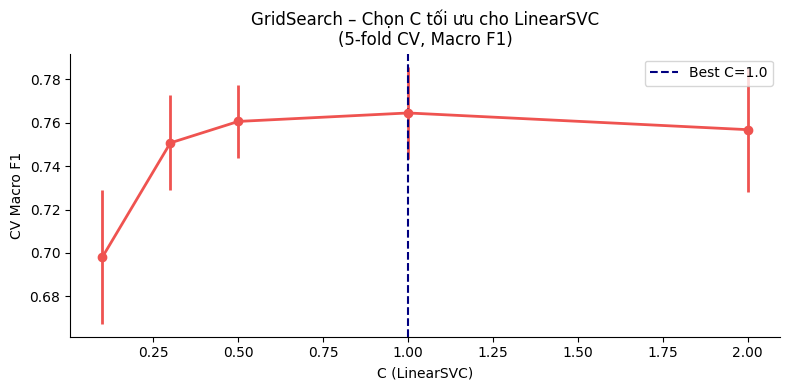

✓ Đã lưu GridSearch results


In [3]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LinearSVC(max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced'))
])
param_grid = {'clf__C': [0.1, 0.3, 0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
grid = GridSearchCV(pipe, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_tr_td, y_tr)

print(f'\nC tối ưu   : {grid.best_params_}')
print(f'CV Macro F1: {grid.best_score_:.4f}')

gs = pd.DataFrame(grid.cv_results_)[['param_clf__C','mean_test_score','std_test_score']]
gs.columns = ['C','CV Macro F1 (mean)','Std']
gs = gs.round(4)
print(gs.to_string(index=False))

# Biểu đồ
fig, ax = plt.subplots(figsize=(8,4))
ax.errorbar(gs['C'], gs['CV Macro F1 (mean)'], yerr=gs['Std'],
            marker='o', color='#EF5350', linewidth=2)
ax.axvline(grid.best_params_['clf__C'], ls='--', color='navy',
           label=f'Best C={grid.best_params_["clf__C"]}')
ax.set_xlabel('C (LinearSVC)'); ax.set_ylabel('CV Macro F1')
ax.set_title('GridSearch – Chọn C tối ưu cho LinearSVC\n(5-fold CV, Macro F1)', fontsize=12)
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/gridsearch_C.png', dpi=150)
plt.show()
gs.to_csv(f'{RESULTS}/gridsearch_results.csv', index=False)
print('✓ Đã lưu GridSearch results')

## 2. Ablation Study – Title vs Description vs Kết hợp

In [4]:
# Kiểm tra title không phải shortcut/leakage
cases = [
    ('Description only', df['description_clean']),
    ('Title only',       df['title_sach']),
    ('Title + Desc',     df['title_va_mo_ta']),
]
abl = []
for name, X in cases:
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=RANDOM_SEED,stratify=y)
    p = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced'))
    ])
    p.fit(Xtr,ytr); pred=p.predict(Xte)
    abl.append({'Đặc trưng': name,
                'Accuracy' : round(accuracy_score(yte,pred),4),
                'Macro F1' : round(f1_score(yte,pred,average='macro',zero_division=0),4)})

abl_df = pd.DataFrame(abl)
print('=== ABLATION STUDY ===')
print(abl_df.to_string(index=False))
t_f1 = abl_df[abl_df['Đặc trưng']=='Title only']['Macro F1'].values[0]
d_f1 = abl_df[abl_df['Đặc trưng']=='Description only']['Macro F1'].values[0]
c_f1 = abl_df[abl_df['Đặc trưng']=='Title + Desc']['Macro F1'].values[0]
print(f'Title-only đạt cao nhất: {t_f1:.4f} > {c_f1:.4f} (Kết hợp) > {d_f1:.4f} (Desc-only)')
print('→ Nhận xét: Đặc trưng Title có sức mạnh chi phối cực lớn (nguy cơ Shortcut).')
print('→ Khi kết hợp thêm Description, điểm giảm nhẹ (<1%) do bị nhiễu, nhưng giúp ranh giới tổng quát hơn.')

abl_df.to_csv(f'{RESULTS}/ablation_study.csv', index=False)
print('✓ Đã lưu ablation_study.csv')

=== ABLATION STUDY ===
       Đặc trưng  Accuracy  Macro F1
Description only    0.7296    0.7219
      Title only    0.8290    0.8216
    Title + Desc    0.8208    0.8147
Title-only đạt cao nhất: 0.8216 > 0.8147 (Kết hợp) > 0.7219 (Desc-only)
→ Nhận xét: Đặc trưng Title có sức mạnh chi phối cực lớn (nguy cơ Shortcut).
→ Khi kết hợp thêm Description, điểm giảm nhẹ (<1%) do bị nhiễu, nhưng giúp ranh giới tổng quát hơn.
✓ Đã lưu ablation_study.csv


## 3. Bảng so sánh các cấu hình C tuần 4

In [5]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_v = tfidf.fit_transform(X_tr_td)
Xte_v = tfidf.transform(X_te_td)

configs = [
    ('SVM C=0.1', LinearSVC(C=0.1,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('SVM C=0.3', LinearSVC(C=0.3,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('SVM C=0.5', LinearSVC(C=0.5,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('SVM C=1.0', LinearSVC(C=1.0,max_iter=3000,random_state=RANDOM_SEED,class_weight='balanced')),
    ('LR  C=1.0', LogisticRegression(C=1.0,max_iter=1000,random_state=RANDOM_SEED,class_weight='balanced')),
]
rows_c = []
for name, clf in configs:
    clf.fit(Xtr_v, y_tr); pred=clf.predict(Xte_v)
    rows_c.append({'Cấu hình': name,
                   'Accuracy': round(accuracy_score(y_te,pred),4),
                   'Macro F1': round(f1_score(y_te,pred,average='macro',zero_division=0),4),
                   'Weighted F1': round(f1_score(y_te,pred,average='weighted',zero_division=0),4)})

df_c = pd.DataFrame(rows_c)
print('=== SO SÁNH CÁC CẤU HÌNH TUẦN 4 ===')
print(df_c.to_string(index=False))
print('\n→ SVM C=1.0 cho Macro F1 cao nhất → chọn làm mô hình tối ưu T4')
df_c.to_csv(f'{RESULTS}/model_tuning_results.csv', index=False)
print('✓ Đã lưu model_tuning_results.csv')


=== SO SÁNH CÁC CẤU HÌNH TUẦN 4 ===
 Cấu hình  Accuracy  Macro F1  Weighted F1
SVM C=0.1    0.7557    0.7514       0.7540
SVM C=0.3    0.8029    0.8039       0.8027
SVM C=0.5    0.8046    0.7911       0.8053
SVM C=1.0    0.8208    0.8147       0.8196
LR  C=1.0    0.7492    0.7553       0.7452

→ SVM C=1.0 cho Macro F1 cao nhất → chọn làm mô hình tối ưu T4
✓ Đã lưu model_tuning_results.csv
